# V1 Model using Apache Cerebrum

This notebook walks through the  Cerebrum workflow to construct
a simple *V1* model. This notebook 
- overviews the data sources configuration,
- explore the downloaded data,
- build the model from code,
- run the simulation, and finally 
- visualize the simulation outputs.  

### Cerebrum Workflow Structure

<div>
<img src="img/Workflow.png" width="500"/>
</div>


The workflow steps to construct a model in Cerebrum are as
follows (as shown in the figure above): 

1. Query and download the requisite data from public databases.
   In case of V1, we acquire data from the following databases:
     - Allen Model Database,
     - Allen Brain Atlas
     - Synaptic Physiology datasets. 
2. Map the acquired data to the relevant regions of the model to be built. 
3. Fill-in any missing details via an optional user-defined **custom mod** definitions. 
4. Realize the final network of neurons in the SONATA format.


### Model Recipe

Model Recipe (files in sub-folder `recipes/v1`) defines key components for constructing a Network with Cerebrum. 

- **Data Providers:** Links to source database and query parameters
- **Filter and Transformers:** Data processing workflow such as filtering via selection criteria on the queried data.
- **Data2Model Mappers:** Mapper methods that map data to model components.
- **User Modifications:** Descriptions of user additions/removals to the purely data-driven model

The following figure shows the overall structure of a Model recipe definition.

<div>
<img src="img/Recipe.png" width="600"/>
</div>

## Install dependencies in a `conda` environment 

The Notebook is expected to be run in a `conda` environment,
in which `cerebrum` and other dependcies installed. 
See the [README.md](README.md) file for the instructions to
create the environment.

In [1]:
from airavata_cerebrum.recipe import RecipeSetup, ModelRecipe
from airavata_cerebrum.model.structure import Network
from airavata_cerebrum.view.tree import DataSourceRecipeView, Data2ModelRecipeView, NetworkStructureView
#
from src import model as v1model
from src import operations as v1ops
from src import params as v1params
#
import nest
from nest.lib.hl_api_sonata import SonataNetwork
from nest.lib.hl_api_nodes import Create as NestCreate
from nest.lib.hl_api_connections import Connect as NestConnect
from nest.lib.hl_api_types import NodeCollection


             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.10.0-rc.2
 Built  : May  7 2026 05:58:33

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



# V1 Recipe Description
## V1 Model Recipe

The Cerebrum V1 model recipe includes the following three sections. For V1, the model recipe is defined by a collection of human-readable json files in the  directory `recipes/v1`.

1. **source_data**
    - Describes how the source databases are connected.
    - Defines the operations applied to the downloaded data such as filters etc.
    - For V1, the `recipes/v1/recipe_data.json` file contains the **source_data** section.
2. **data2model_map**
    - Describes mapping between source data and different regions of the model.
    - For V1, we have five recipe files, one corresponding each layers of the V1 model that contains the **data2model_map** section, corresponding to each layer.
        - `recipes/v1/recipe_dm_l1.json`
        - `recipes/v1/recipe_dm_l23.json`
        - `recipes/v1/recipe_dm_l4.json`
        - `recipes/v1/recipe_dm_l5.json`
        - `recipes/v1/recipe_dm_l6.json`
3. **custom mod**
    - Describes the user modifications applied after a model skeleton build from the data and mapping ((1) and (2) above).
    - For V1, we have eight different custom mod files, one corresponding to each level of the V1 model -- containing the user **cust mod**s for each layer and the BKG and LGN layers.
        - `recipes/v1/custom_mod_l1.json`
        - `recipes/v1/custom_mod_l23.json`
        - `recipes/v1/custom_mod_l4.json`
        - `recipes/v1/custom_mod_l5.json`
        - `recipes/v1/custom_mod_l6.json`
        - `recipes/v1/custom_mod_ext.json`, `recipes/v1/custom_mod_ext_bkg.json` and `recipes/v1/custom_mod_ext_lgn.json`

***NOTE: The following code loads all the above recipe files an initializes a python `ModelSetup` object that performs basic input validation, and captures all the parameters. Custom modifications are loaded separately as a `cerebrum.structure.Network` object.***

In [2]:
#
# The following code initializes the parameters of the model
params = v1params.RecipeParams()
params.ncells = 30000
#
# After setting the model parameters, we create a ModelSetup object
# that builds a framework with some simple valiations
md_recipe_setup = params.recipe_setup()

#
# Custom mods are built as a separate object, which will be 
# combined later after a skeleton is built.
custom_mod_struct = Network.from_file_list(params.custom_mod) 

## Exploring the Source Data Section

Cerebrum includes modules that can download data from multiple
data provider modules. It includes
- Methods for defining the querying from the database and
  filter the data based on specific criteria. 
- Utilities to visualize the data provider configurations in
  easy-to-understand explorer view inside Jupyter notebook
  with the relevant parameters displayed in the side panel.

Cerebrum Construction of Mouse V1 is enabled by data with 
three different data providers: 
- Allen Cell Types database,
- Allen Brain Cell Atlas,
- AI Synaptic Physiology Database, and
- Gouwens et. al. (2019) neuron classification based on
  electrophysiolocial data.

***NOTE: Running code below within the jupyter notebook will display
the structure of the recipe's source_data section***

In [3]:
import IPython.display
##
## Displays in the ipython notebook, the structure of source data
IPython.display.JSON(md_recipe_setup.get_section('source_data'))

<IPython.core.display.JSON object>

### Visualize Source Data

Cerebrum also provides a Jupyter Notebook Widgets that
aids the visualization of the source data configration.
The `DataSourceRecipeView` renders the data source 
information and query parameters in a user friendly output
as compared to the strict names in json file. 

<div>
<img src="img/SourceData.png" width="600"/>
</div>

**NOTE: Running the code below with show an interactive explorer-like tree structure as shown in the image above**

In [5]:
sd_tree = DataSourceRecipeView(md_recipe_setup, left_width="55%")
sd_tree.build()
sd_tree.layout

TwoByTwoLayout(children=(<awitree.Tree object at 0x1554386c7b50>,), layout=Layout(grid_template_areas='"top-le…

## Data2Model Mapping

Definitions for data2model_map includes two subsections:

`data2model_map` section of the recipe includes two subsections:

1. *Locations:*
    - Locations are hiearchially defined and each sub-location
      declares the links to the acquired data.
    - For __V1__, (i) acquired cell types information from Cell types
      database maps to the neuron models, and
      (ii) the summary information from MERFISH single-cell atlas
      map to the distribution of neuron types.
    - For __V1__, we map eight different neuron types to the specific
      models and the region fractions. 
2. *Connections:*
    - Connections are defined as a set of pairs to neurons,
      with pair defining the data links.
    - AI synaptic physiology data is mapped to the connection
      probabilities between the pairs of neuron classes.
    - For __V1__, we map each of the different neuron pairs to the
      AI Syn. Phys. Data outputs

***NOTE: Running code below within the jupyter notebook will display the 
tree structure of the data2model section from the json files***

In [6]:
import IPython.display

IPython.display.JSON(md_recipe_setup.get_section('data2model_map'))

<IPython.core.display.JSON object>

### Visualize Data2Model Mapping

Similar to Source Data section, Cerebrum also provides a Jupyter Notebook Widget
to visualize the data2model section of the recipe.
The `Data2ModelRecipeView` renders with a user friendly output compared to
the strict names in json file. 

<div>
<img src="img/Data2Model.png" width="600"/>
</div>

***NOTE: Running the Recipe View code below will display the Tree widget (as shown in the above snapshot), when run inside the Jupyter notebook***

In [7]:
dm_tree = Data2ModelRecipeView(md_recipe_setup, width="55%")
dm_tree.build()
dm_tree.layout

TwoByTwoLayout(children=(<awitree.Tree object at 0x1554363ff490>,), layout=Layout(grid_template_areas='"top-le…

## Custom Modifications

Through the custom modification json files,users can
provide additional details required for network
construction. They can include information that are either
(a) not available in the linked databases or
(b) not applicable for the model being built and over-ride it.


For the Mouse V1, custom modifications include:

1. Dimensions of each region in the model.
2. Connection Parameters not available within the AI Syn. Phys. database.
3. Details of the networks that are external to V1 : LGN and the background networks. 


***NOTE: Running code below within the jupyter notebook will display the tree 
structure of the data2model section from the json files***

In [8]:
import IPython.display

IPython.display.JSON(custom_mod_struct.model_dump())

<IPython.core.display.JSON object>

### Visualize Custom Mod structure

Similar to Source Data section, Cerebrum also provides a  Jupyter Notebook Widget based visualization of the the custom modifications, which renders with user friendly output compared to the strict names in json file.

**NOTE::**
1. ***Running the Recipe View code below will display the Tree widget
(as shown in the above snapshot), when run inside the Jupyter notebook***
2. ***Due to Size Restrictions, this view doesn't work in ipython for now
(It does work with marimo)***

In [ ]:
cmod_view = cbm_tree.NetworkStructureView(custom_mod_struct, left_width="55%")
cmod_view.build()
cmod_view.layout

## Mapper classess for  Network construction
To realize model recipe to SONATA Network, three python classes that translate from the model skeleton to neurons and connections.

1. *Region Mapper* : Defined in `mousev1.model.V1RegionMapper`, maps the location data gathered from data sources/user mods to a region in the network.
2. *Neuron Mapper* : Defined in `mousev1.model.V1NeuronMapps`, maps the neuron information within in a given location data to a neuron class within the region.
3. *Connection Mapper*: Defined in `mousev1.model.V1ConnectionMapper`, maps the connection data to realize the connection details in the network of neurons.

In addition a *Network Builder* class (`mousev1.model.V1BMTKNetworkBuilder`) is also defined that translates the model description to SONATA network. 

In [9]:
from src.model import (
    V1BMTKNetworkBuilder,
    V1ConnectionMapper,
    V1NeuronMapper,
    V1RegionMapper
)

model_recipe = ModelRecipe(
    recipe_setup=md_recipe_setup,
    region_mapper=V1RegionMapper,
    neuron_mapper=V1NeuronMapper,
    connection_mapper=V1ConnectionMapper,
    network_builder=V1BMTKNetworkBuilder,
    mod_structure=custom_mod_struct,
    save_flag=params.save_flag,
)

# V1 Network Construction from Recipe

## Data Acquistition

Data acquisition consists of the following two steps: 
1. Data download and 
2. Data transformer operations such as filtering and combining
   that are run after downloaded data. 

### Run Workflow to Download Data

After the model description is defined and updated with
custom user modifications, the download workflow proceeds as follows:
1. Query and download the data from all the databases of interest.
2. Apply the filters and transormations.
3. Save downloaded data to a local database.

### Run Post-download Operations

After data is dowloaded, the data obtained from 
different databases need to processed separately:

1.  In case of the Allen Cell Type database, the download step can
    be restricted only to obtain the metadata related to cell types.
    After the meta data is downloaded, we need to acquire the models
    of interest (3 LIF Models). We use the GLIF API from allensdk to
    download these 3LIF model with a explained variance threshold.
    Further filter is applied based on the classification by
   *Gouwens et. al. (2019)*.
3.  For data from Allen Brain Cell Atlas,
    we filter the data specific to only the VISp region.
5.  For AI Syn Phys. data, we select only the neuron pairs of our interest.

We accomplish the above two steps by running `recipe.acquire_source_data()` function.


**TODO:: Uncomment the logging configuration to get detailed logging**

In [10]:
# UNCOMMENT THE FOLLOWING TO GET detailed logging
#import logging
#logging.basicConfig(level=logging.INFO)
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    db_source_data = model_recipe.acquire_source_data()

  /storage/ideas/is-schockalingam6-0/dev/test/airavata-cerebrum/examples/v1/cache/ai_synphys/database/synphys_r2.1_small.sqlite
  [####################]  100.00% (176.77 MB / 176.8 MB)  16.674 MB/s  0:00:00 remaining
  done.


## Explore downloaded data

Output data are stored in json format in the directory
`data/v1/db_connect_output.json`, which can be examined
with json library. Here are examples of Region and Neuron
fractions of the Allen Brain Atlas, and connectivity matrix
downloaded from AI Syn. Phys. dataset. 

Output data is also stored as duckdb database
`data/v1/db_connect_output.db`,
which can be used for more detailed queries.

In [11]:
import json
#
with open("./data/v1/db_connect_output.json") as dbf:
    db_out_data = json.load(dbf)


### Regional Neuron Distributions from Mouse Brain Atlas

In [12]:
import airavata_cerebrum.dataset.abc_mouse as abcm
abcm.DFBuilder.build(db_out_data['airavata_cerebrum.dataset.abc_mouse'])

Region,Layer,nregion,inhibitory fraction,fraction wi. region,Vip fraction,Pvalb fraction,Sst fraction,Lamp5 fraction,Sst-Chodl fraction,IT-ENT fraction,IT-CTX fraction,IT-Other fraction,ET fraction,CT fraction,NP fraction,IT fraction
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""VISp""","""1""",61884,0.405155,0.069663,0.147583,0.038168,0.035623,0.720102,0.007634,0.001733,0.986135,0.001733,0.0,0.0,0.0,0.989601
"""VISp""","""2/3""",61884,0.078755,0.34862,0.31669,0.332382,0.161912,0.158345,0.00214,0.0,1.0,0.0,0.0,0.0,0.0,1.0
"""VISp""","""4""",61884,0.111916,0.209699,0.131933,0.532773,0.315126,0.018487,0.0,0.0,0.962618,0.0,0.029334,0.000212,0.007413,0.962618
"""VISp""","""5""",61884,0.165428,0.177606,0.021739,0.487681,0.455797,0.022464,0.006522,0.001867,0.519247,0.000144,0.323039,0.043953,0.104137,0.521258
"""VISp""","""6a""",61884,0.062779,0.163661,0.038321,0.562044,0.34854,0.025547,0.010949,0.001711,0.212443,0.001834,0.000611,0.75932,0.005378,0.215988
"""VISp""","""6b""",61884,0.05291,0.030751,0.0375,0.475,0.275,0.0875,0.075,0.0,0.042598,0.00419,0.0,0.725559,0.0,0.046788


### Connectivity probability from AI Syn. Phys.

In [13]:
import airavata_cerebrum.dataset.ai_synphys as aisp
aisp.DFBuilder.build(db_out_data['airavata_cerebrum.dataset.ai_synphys'])

pre_synapse,post_synapse,connect_prob
str,str,f64
"""L23-Pyr""","""L23-Pyr""",0.072655
"""L23-Pyr""","""L23-Pvalb""",0.538204
"""L23-Pyr""","""L23-Sst""",0.386245
"""L23-Pyr""","""L23-Vip""",0.207773
"""L23-Pyr""","""L4-Pyr""",0.056222
…,…,…
"""L6-Vip""","""L5-Vip""",0.039576
"""L6-Vip""","""L6-Pyr""",0.0
"""L6-Vip""","""L6-Pvalb""",0.064641


## Source data to Model mapping

In this step, the data downloaded is mapped to the locations and the connection pairs as mentioned in "Data2Model Map" section above.


**NOTE: Uncomment the logging configuration to get detailed logging**

In [14]:
#import logging
#logging.basicConfig(level=logging.INFO)
#
msrc = model_recipe.map_source_data()

## Apply Custom Modification
As mentioned in the "Custom Modifications" section above,
user updates for the model are loaded from the `custom mod` files.

For V1, the user modification include dimension, additional
connection properties, and properties of external networks.


In [15]:
IPython.display.JSON(custom_mod_struct.model_dump())

<IPython.core.display.JSON object>

In [16]:
msrc = model_recipe.build_net_struct()
msrc = model_recipe.apply_mod(params.ncells)

## Build Network with BMTK 

### Skeleton Network → Graph of neurons

The output of *mapping source data* + *applying custom modifications*
is a skeleton representation of the model.
In this step this skeletion is used to initialize
the nodes and edges of a multi-graph of neurons using BMTK.

***NOTE:: The code below skips saving the file as saving consumes significant
amount of time. Building first is useful to first verify any errors***

In [17]:
bmtk_net_builder = V1BMTKNetworkBuilder(model_recipe.network_struct)
bmtk_net = bmtk_net_builder.build()

### Save SONATA

Save the network as as SONATA format with BMTK

***NOTE: Skipping Save SONTA as it takes a siginificant amount of time.
For a model of 30K cells, it takes about an hour. 
(Previously built files are made available in "./builds/v1030" folder)*** 

In [ ]:
bmtk_net_builder.save(str(md_recipe_setup.network_dir))

# Simulation and Analysis

## Prepare neuron model files for NEST

The format of the glif-model description json files downloaded from the
cell types database is not compatible with NEST simulator.

In this step we convert to the appopriate format that is expected from NEST.


In [18]:
# Converting to 
import src.operations as ops
import nest
import matplotlib.pyplot as plt
import os

output_path = "./components/cell_models/"
input_path = "./components/point_neuron_models/"

if not os.path.exists(output_path):
    os.mkdir(output_path)

ops.convert_ctdb_models_to_nest(output_dir=output_path, input_dir=input_path)

## Simulate the SONATA Network in NEST

### SONATA Network Config 

This NEST config file is manually created, and refers to the network files generated by Cerebrum.
We explore the config file below.

In [19]:
import json
import IPython.display
import pandas as pd
import seaborn as sns
#
from src import simulate_cli 
from src.sonata_df import spikes_df, nodes_df, node_types_df, lgn_df

with open("./builds/v1030/config.json") as ifx:
    cfg_dict = json.load(ifx)

IPython.display.JSON(cfg_dict)

<IPython.core.display.JSON object>

### Run Simulation

In [21]:
import os
import shutil
output_path = "./builds/v1030/output/"

if os.path.exists(output_path):
    shutil.rmtree(output_path)

simulate_cli.main("./builds/v1030/config.json", 16)

2026-05-29 16:49:41,455 [INFO] Created log file


/storage/ideas/is-schockalingam6-0/phe/spack/opt/spack/linux-cascadelake/miniforge3-24.3.0-0-xgjqahntab2nzxf2nfab5k5ixrky2z2n/envs/cbm_test/lib/python3.10/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
Provided for backward compatibility only. Set `nest.verbosity = nest.VerbosityLevel.XYZ` instead.


2026-05-29 16:49:42,088 [INFO] Batch processing nodes for v1/0.
2026-05-29 16:49:42,184 [INFO] Batch processing nodes for lgn/0.
2026-05-29 16:49:42,195 [INFO] Batch processing nodes for bkg/0.
2026-05-29 16:49:43,313 [INFO] Setting up output directory
2026-05-29 16:49:43,315 [INFO] Building cells.
2026-05-29 16:49:45,942 [INFO] Building recurrent connections
2026-05-29 16:50:01,370 [INFO] Network created.
2026-05-29 16:50:01,373 [INFO] Build virtual cell stimulations for LGN_spikes


/storage/ideas/is-schockalingam6-0/phe/spack/opt/spack/linux-cascadelake/miniforge3-24.3.0-0-xgjqahntab2nzxf2nfab5k5ixrky2z2n/envs/cbm_test/lib/python3.10/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
SetStatus() is deprecated and will be removed in a future version of NEST. Instead of SetStatus(nrns|conns, args), use nrns|conns.set(args).


2026-05-29 16:50:28,084 [INFO] Build virtual cell stimulations for BKG_spikes
2026-05-29 16:50:29,217 [INFO] Starting Simulation
2026-05-29 16:50:48,246 [INFO] Simulation finished, finalizing results.
2026-05-29 16:50:50,672 [INFO] Done.


In [22]:
lgndf = lgn_df("./lgn/full3_GScorrected_PScorrected_3.0sec_SF0.04_TF2.0_ori270.0_c100.0_gs0.5_spikes.trial_0.h5")
lgndf

,gid,time
0,0,677.465750
1,0,706.951454
2,0,716.273214
3,0,759.103046
4,0,809.736841
...,...,...
337641,17399,2711.425680
337642,17399,2723.924696
337643,17399,2733.776178
337644,17399,2799.512497


## Analysis of Simulation outputs

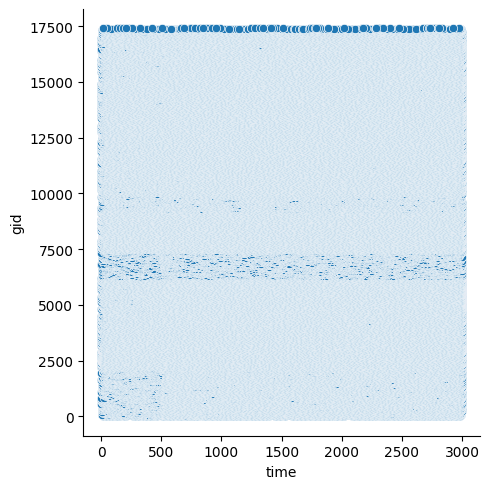

In [23]:
sns.relplot(data=lgndf, x="time", y="gid")

In [24]:
spikes_df = spikes_df("./builds/v1030/output/spikes.h5")
nodes_df = nodes_df("./builds/v1030/network/v1_nodes.h5")
node_types_df = node_types_df("./builds/v1030/network/v1_node_types.csv")

node_spikes_df = pd.merge(pd.merge(spikes_df, nodes_df), node_types_df)
node_spikes_df

,node_id,timestamp,y,node_type_id,ei,location,pop_name,layer,cell_type
0,250,470.25,-166.479898,482654108,i,VISp1,"('1', 'Htr3a')",'1','Htr3a'
1,250,1736.00,-166.479898,482654108,i,VISp1,"('1', 'Htr3a')",'1','Htr3a'
2,250,1310.50,-166.479898,482654108,i,VISp1,"('1', 'Htr3a')",'1','Htr3a'
3,250,481.50,-166.479898,482654108,i,VISp1,"('1', 'Htr3a')",'1','Htr3a'
4,684,1581.75,-78.955271,482654108,i,VISp1,"('1', 'Htr3a')",'1','Htr3a'
...,...,...,...,...,...,...,...,...,...
311480,23946,1151.25,-800.116409,503286448,e,VISp6,"('6', 'Ntsr1')",'6','Ntsr1'
311481,23946,685.75,-800.116409,503286448,e,VISp6,"('6', 'Ntsr1')",'6','Ntsr1'
311482,23509,2759.75,-702.354838,485905411,e,VISp6,"('6', 'Ntsr1')",'6','Ntsr1'
311483,27240,1844.50,-715.062022,502382506,i,VISp6,"('6', 'Sst')",'6','Sst'


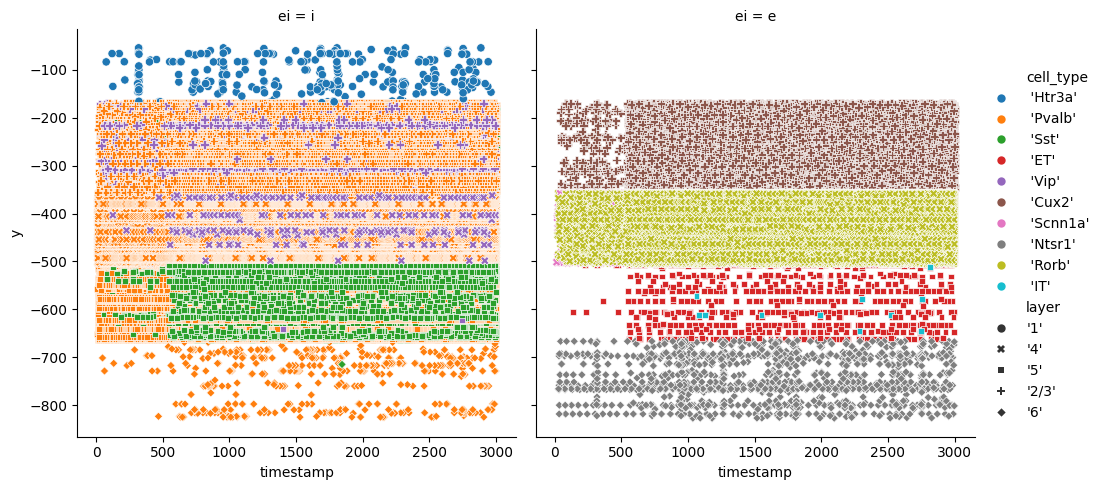

In [25]:
sns.relplot(data=node_spikes_df, x="timestamp", y="y", col="ei", hue="cell_type", style="layer")

In [26]:
import matplotlib.pyplot as plt
from src import plotting_utils as mpu

pointnet_config = 'builds/v1030/full_path_config.json'
net = 'full'
sortby='tuning_angle'
radius = 400.0


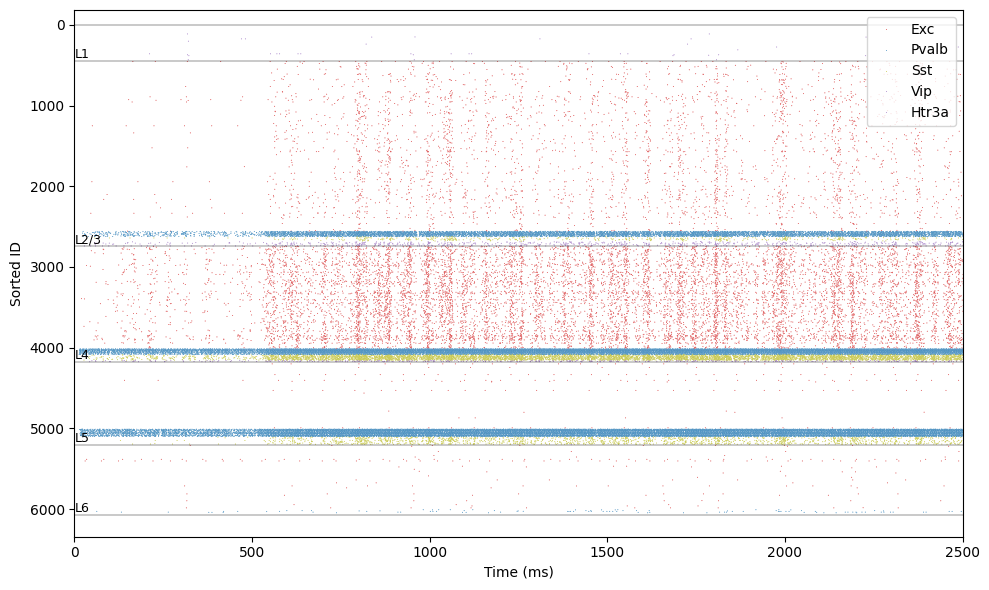

In [27]:
plt.figure(figsize=(10, 6))


ax = mpu.plot_raster(pointnet_config, sortby=sortby, **mpu.settings[net])
ax.set_xlim([0, 2500])
plt.tight_layout()

In [28]:
spikes_df, hue_order, color_dict, layer_divisions = mpu.make_figure_elements(pointnet_config, radius, sortby)
# calculate firing rates
rates = spikes_df[spikes_df['timestamps']>500.0].groupby(['Sorted ID'])['timestamps'].count()/2.5
rates = rates.reset_index(name = 'Mean Rate')
rates_df = spikes_df[['population', 'Sorted ID', 'Cell Type', 'Tuning Angle', 'layer']].drop_duplicates('Sorted ID')
rates_df = rates_df.merge(rates, how='left', left_on='Sorted ID', right_on = 'Sorted ID')

<Axes: xlabel='layer', ylabel='Mean Rate'>

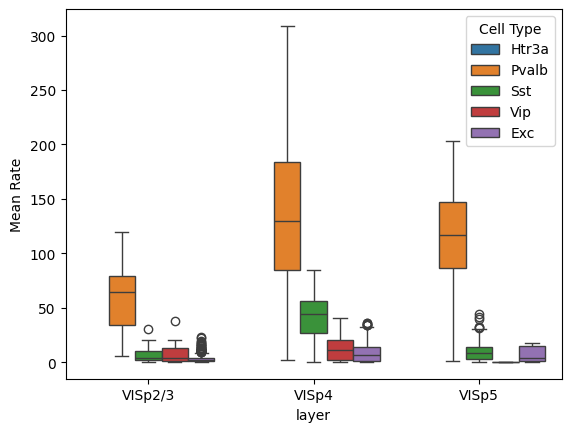

In [29]:
import seaborn as sns
sns.boxplot(rates_df, x='layer', y='Mean Rate', hue='Cell Type', order=['VISp2/3', 'VISp4', 'VISp5'])

<Axes: xlabel='layer', ylabel='Mean Rate'>

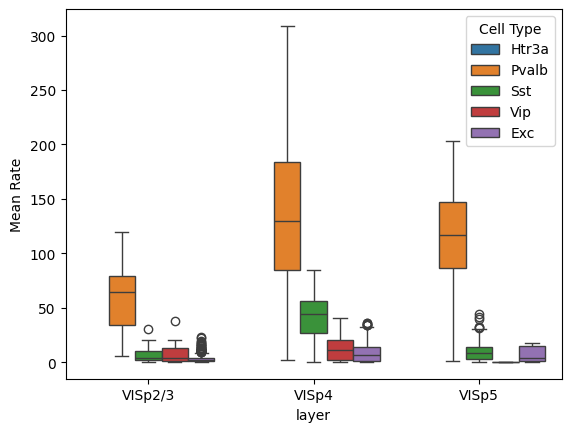

In [30]:
import seaborn as sns
sns.boxplot(rates_df, x='layer', y='Mean Rate', hue='Cell Type', order=['VISp2/3', 'VISp4', 'VISp5'])

In [31]:
angles_list = [0.0, 45.0, 90.0, 135.0, 180.0, 225.0, 270.0, 315.0, 360.0]
rates_df['Tuning Angle'] = rates_df['Tuning Angle'].round()
rates_df = rates_df[rates_df['Tuning Angle'].isin(angles_list)]


<Axes: xlabel='Tuning Angle', ylabel='Mean Rate'>

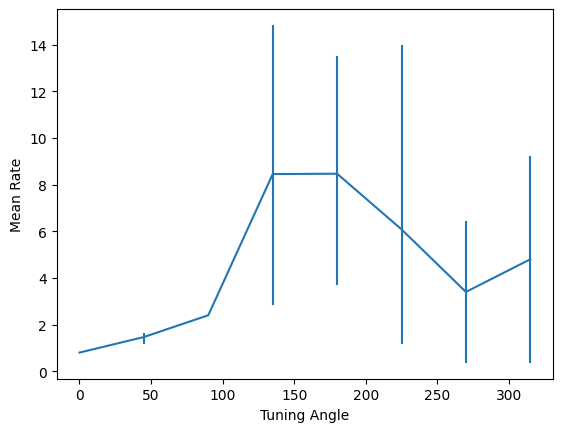

In [32]:
sns.lineplot(rates_df[rates_df['Cell Type']=='Exc'], x='Tuning Angle', y='Mean Rate', err_style='bars')

<Axes: xlabel='Tuning Angle', ylabel='Mean Rate'>

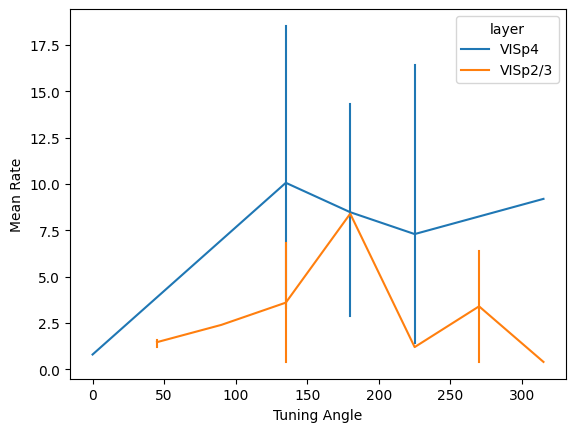

In [33]:
sns.lineplot(rates_df[rates_df['Cell Type']=='Exc'], x='Tuning Angle', y='Mean Rate', hue = 'layer', err_style='bars')

# Simple Updates to the Model

The advantage of Cerebrum is that it provides the following different ways one can update the model:

1. Directly Update the json files to add update queries/parameters
2. Load only parts of json by splitting into differnet files and selectively load them.
3. Custom database query classes by subclassing DBQuery.
4. Custom database mapper functions by subclassing OpXformer.
5. Custom SONATA network builder, neuron mapper, region mapper classes that will select how neurons are generated and how they are connected.


***The following code shows how to select only the layer L4 of the V1 model and build a network***

In [ ]:
def data_mapped_model(levels: tuple[str,...]=("L1", "L23", "L4")):
    params = mousev1.params.RecipeParams(levels=list(levels))
    mdrcp = params.model_recipe()
    mdrcp.map_source_data()
    mdrcp.build_net_struct()
    mdrcp.apply_mod()
    mdrcp.build_network()

data_mapped_model(("L4"))

***The following code demonstrates how to run V1 with 40,000 Cells instead of 30,000 cells***

In [ ]:
def data_mapped_model(ncells=30000):
    params = mousev1.params.RecipeParams(ncells=ncells)
    mdrcp = params.model_recipe()
    mdrcp.map_source_data()
    mdrcp.build_net_struct()
    mdrcp.apply_mod()
    mdrcp.build_network()

data_mapped_model(ncells=40000)